# Раздел 1. Основы теории вероятностей
---

## Тема 1. Геометрическое определение вероятности
---

In [1]:
import numpy as np
import matplotlib.pyplot as plt

### Задача
> В стену вмонтирован игровой круг, площадь которого в два раза меньше площади стены. Дротик бросают наудачу, в стену он попадает обязательно. Найти вероятность попадания в круг.

Исходов здесь бесконечно много, поэтому классическое определение не работает. Пользуемся **геометрическим определением**: вероятность попасть в часть $A$ области $B$ равна отношению площадей

$P(A) = \frac{S_A}{S_B}$

По условию площадь круга $S_{кр} = \frac{S}{2}$, значит

$P(A) = \frac{S/2}{S} = \frac{1}{2} = 0{,}5$

Размеры стены на ответ не влияют, но для моделирования их надо задать. Пусть стена — квадрат со стороной $2$ м, тогда $S = 4$ м², $S_{кр} = 2$ м², а радиус находим из $\pi R^2 = 2$.

In [2]:
a = 2                      # сторона стены, м
S = a**2                   # площадь стены
R = np.sqrt(S / 2 / np.pi) # радиус круга

print("S =", S, " S круга =", S / 2, " R =", round(R, 4))
round((S / 2) / S, 4)

S = 4  S круга = 2.0  R = 0.7979


0.5

### Моделирование

Один бросок — случайная точка $(x, y)$. Дротик в круге, если $x^2 + y^2 \leqslant R^2$. Бросим $10\,000$ дротиков и посчитаем долю попаданий.

In [3]:
n = 10000
x = np.random.uniform(-a / 2, a / 2, n)
y = np.random.uniform(-a / 2, a / 2, n)
hit = x**2 + y**2 <= R**2  # поэлементное сложение, получим массив из T/F (считаем, как 1/0)

print("попало в круг:", hit.sum(), "из", n)
round(hit.mean(), 4)

попало в круг: 5017 из 10000


np.float64(0.5017)

Частота близка к $0{,}5$. С ростом числа бросков она всё точнее приближается к теоретической вероятности:

In [4]:
for n_i in [100, 1000, 10000, 100000]:
    x_i = np.random.uniform(-a / 2, a / 2, n_i)
    y_i = np.random.uniform(-a / 2, a / 2, n_i)
    p_i = (x_i**2 + y_i**2 <= R**2).mean()
    print(f"n = {n_i}:  m/n = {p_i}")

n = 100:  m/n = 0.49
n = 1000:  m/n = 0.513
n = 10000:  m/n = 0.4939
n = 100000:  m/n = 0.49991


### Иллюстрация

Нарисуем стену, круг и точки попаданий (первые $1500$ бросков).

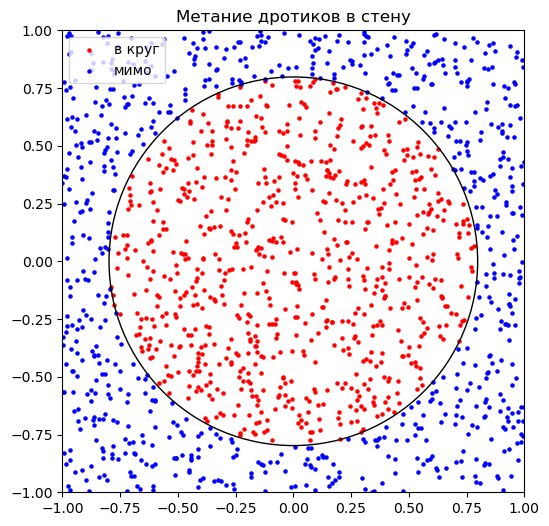

In [5]:
k = 1500
plt.figure(figsize=(6, 6))
# рисуем попавшие точки
plt.scatter(x[:k][hit[:k]], y[:k][hit[:k]], s=5, color="red", label="в круг")   # массив hit работает, как фильтр точек (брать/не брать)
# рисуем промахи (~ отрицание)
plt.scatter(x[:k][~hit[:k]], y[:k][~hit[:k]], s=5, color="blue", label="мимо")
plt.gca().add_patch(plt.Circle((0, 0), R, fill=False, color="black"))  # рисуем круг для отметки попаданий
plt.gca().set_aspect("equal")  # ставим одинаковый масштаб по осям x и y (чтобы круг не стал овалом)
plt.xlim(-1, 1)
plt.ylim(-1, 1)
plt.title("Метание дротиков в стену")
plt.legend()
plt.show()

Красных и синих точек примерно поровну — это и есть вероятность $0{,}5$.

**Ответ:** $P(A) = 0{,}5$.